In [6]:
from rdkit import Chem
from rdkit.Chem import AllChem
import random

smiles = "C"  # teste

mol = Chem.MolFromSmiles(smiles)
mol = Chem.AddHs(mol)

AllChem.EmbedMolecule(mol)
AllChem.UFFOptimizeMolecule(mol)


0

In [7]:
ff = AllChem.UFFGetMoleculeForceField(mol)


In [35]:
import numpy as np

T = random.choice([100000])
print(f"Temperatura sorteada: {T} K")

conf = mol.GetConformer()

n_steps = 2000
scale = 0.001 * T  # amplitude proporcional à temperatura

for step in range(n_steps):
    for i in range(mol.GetNumAtoms()):
        pos = np.array(conf.GetAtomPosition(i))
        displacement = np.random.normal(scale=scale, size=3)
        new_pos = pos + displacement
        conf.SetAtomPosition(i, new_pos)
    
    ff.Initialize()
    ff.Minimize(maxIts=10)


Temperatura sorteada: 100000 K


In [36]:
def fragmented(mol, threshold=2.5):
    conf = mol.GetConformer()
    coords = np.array([list(conf.GetAtomPosition(i)) for i in range(mol.GetNumAtoms())])
    
    max_dist = np.max(np.linalg.norm(coords[:,None] - coords[None,:], axis=2))
    return max_dist > threshold

if fragmented(mol):
    print("❌ Fragmentou!")
else:
    print("✅ Sobreviveu!")


✅ Sobreviveu!


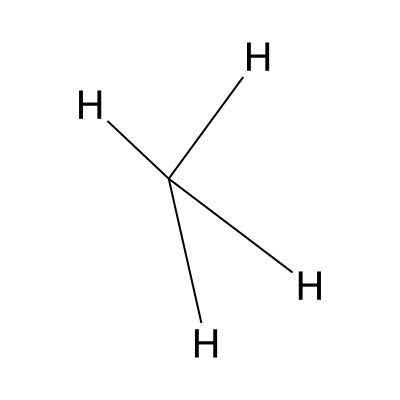

In [37]:
from rdkit.Chem import Draw
Draw.MolToImage(mol, size=(400,400))
